# Module 2.2: Positional Encoding (The Concept of Time)

In the previous notebook, we turned words into dense embedding vectors. Our model now knows the meaning of a word, but it still has a huge blindspot: **it has no concept of order or time**.

## 1. The "Bag of Words" Problem

### The Concept
If you feed a raw neural network the sentence "Dog bites man" and "Man bites dog", the mathematical operations will evaluate exactly the same. Standard attention mechanisms look at all words simultaneously in parallel.

### Why do we need to fix it?
Language is sequential. The meaning of a sentence changes entirely based on word order. Since the Transformer processes the entire sentence at once for extreme speed (unlike older RNNs which read word-by-word), we have to manually inject a "timestamp" or "position tag" directly into the word's DNA (its embedding vector).

## 2. The 2017 Solution: Absolute Sine/Cosine Encoding

### The Analogy (The Theater Tickets)
Imagine a crowd of people walking into a movie theater. To make sure they sit in the right order, you hand them a ticket. 

Why not just give them a ticket with an integer `1, 2, 3, 4`?
- Because sentences can be 10,000 words long. If you add the number `10000` to a delicate neural network embedding `[-0.1, 0.5, 0.2]`, it will completely destroy the mathematical balance of the network.

Instead, the creators of the Transformer decided the "ticket" should be a unique **chord of music**. A chord is made of continuous waves (Sine and Cosine). Every seat in the theater gets a unique visual wavelength pattern between `-1` and `1`.

### Why do we need it?
Using oscillating mathematical waves solves three massive problems:
1. The numbers never blow up (always bounded between -1 and 1).
2. It works for any sequence length (you can always calculate the sine wave further down the line).
3. The network can easily learn to calculate *relative* distances because shifting a sine wave gives you another predictable wave.

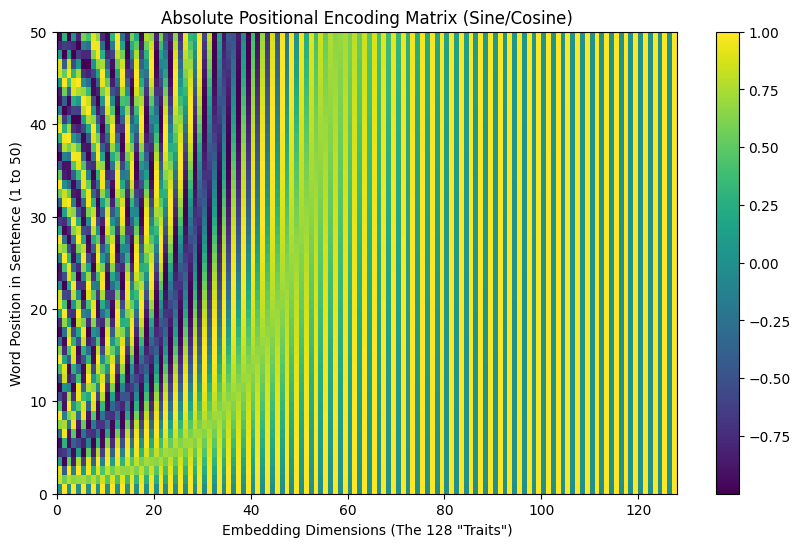

In [1]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt

# A PyTorch implementation of the classic Sine/Cosine Positional Encoding
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 100):
        super().__init__()
        
        # Create a matrix of zeros [Max_Length, Dimensions]
        pe = torch.zeros(max_len, d_model)
        
        # Create a column of positions [0, 1, 2, 3...]
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        
        # Calculate frequencies for the waves
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        # Apply Sine to even columns, Cosine to odd columns
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        self.register_buffer('pe', pe) # Save it to memory without training it
        
    def forward(self, x):
        # Simply ADD the positional "waves" to the word embeddings
        seq_len = x.size(1)
        return x + self.pe[:seq_len, :]

# Let's visualize what the "Theater Tickets" look like for 50 words with 128 traits
pe_layer = PositionalEncoding(d_model=128, max_len=50)
dummy_word_embeddings = torch.zeros(1, 50, 128) # Fake batch of zeros
positioned_words = pe_layer(dummy_word_embeddings)

plt.figure(figsize=(10, 6))
plt.pcolormesh(positioned_words[0].numpy(), cmap='viridis')
plt.xlabel('Embedding Dimensions (The 128 "Traits")')
plt.ylabel('Word Position in Sentence (1 to 50)')
plt.title('Absolute Positional Encoding Matrix (Sine/Cosine)')
plt.colorbar()
plt.show()

## 3. The Modern Era: Rotary Positional Embeddings (RoPE) 🚀

### The Concept
While the 2017 Sine/Cosine method (Absolute Encoding) *adds* the position to the embedding, modern models like Llama 3 and Mistral use **Rotary Positional Embeddings (RoPE)**.

### The Analogy (The Clock Hand)
Imagine your word embedding is the hand of a clock pointing at 12 o'clock. 

Instead of *adding* a ticket number to the embedding, RoPE says: "Take the embedding vector and physically **rotate** it by X degrees, where X is its position in the sentence."
- Word 1 is rotated 10 degrees.
- Word 2 is rotated 20 degrees.

### Why do we need it?
RoPE elegantly solves the problem of **relative distance**. If the model wants to know if Word 1 and Word 2 are near each other, it just checks the angle between them (it is always exactly 10 degrees apart!). No matter if the words are at positions 1 and 2, or positions 1001 and 1002, the geometric angle between them is identical. 

This makes models *insanely* good at understanding structure over massive contexts (like books or codebases).